In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [2]:
# Load your dataset (assuming df has a DateTime index)
df = pd.read_csv("E:/Project/Submissions/Datasets/df_reduced_pca.csv")
y = df["energy_sum"].values.reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
y_scaled = scaler.fit_transform(y)


In [3]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Define sequence length (e.g., last 30 days used for prediction)
seq_length = 30
X, y = create_sequences(y_scaled, seq_length)

# Split into train and test (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Input data
X_train = np.array([[[3], [1], [4], [5], [2]], 
                    [[6], [1], [7], [2], [0]]], dtype=np.float32)  # Ensure dtype is float32

# Labels (for regression task, example)
y_train = np.array([1, 0], dtype=np.float32)  # Example regression labels


model = Sequential()

# First LSTM layer with L2 regularization
model.add(LSTM(50, return_sequences=True, kernel_regularizer=l2(0.001), input_shape=(30, 1)))  
model.add(Dropout(0.3))  # Increase dropout slightly

# Second LSTM layer with L2 regularization
model.add(LSTM(50, return_sequences=False, kernel_regularizer=l2(0.001)))  
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')


# Build the LSTM model
#model = Sequential([
#    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
#   Dropout(0.2),
#  LSTM(50, return_sequences=False),
#    Dropout(0.2),
#    Dense(1)  # Output layer
#])
#model.add(LSTM(50, return_sequences=True, kernel_regularizer=l2(0.001)))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])


Epoch 1/50


C:\Users\ABCD\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.7179 - val_loss: 0.1409
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 1.1022 - val_loss: 0.1940
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.6301 - val_loss: 0.2655
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.4764 - val_loss: 0.3526
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.4414 - val_loss: 0.4580
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.3151 - val_loss: 0.5843


18435/18435 ━━━━━━━━━━━━━━━━━━━━ 137s 7ms/step


C:\Users\ABCD\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


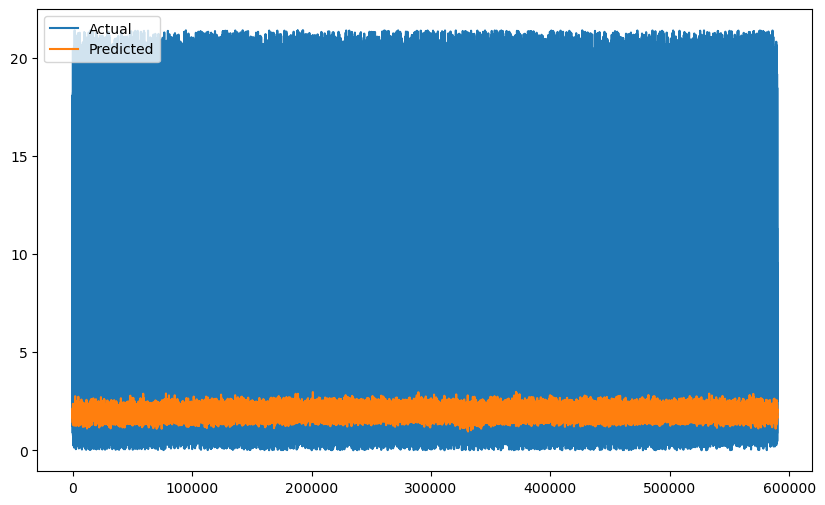

In [5]:
# Make predictions
y_pred = model.predict(X_test)

# Inverse transform predictions
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))

# Plot results
plt.figure(figsize=(10,6))
plt.plot(y_test_inv, label="Actual")
plt.plot(y_pred_inv, label="Predicted")
plt.legend()
plt.show()

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)  # RMSE is the square root of MSE

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 0.29
Mean Squared Error (MSE): 0.12
Root Mean Squared Error (RMSE): 0.35


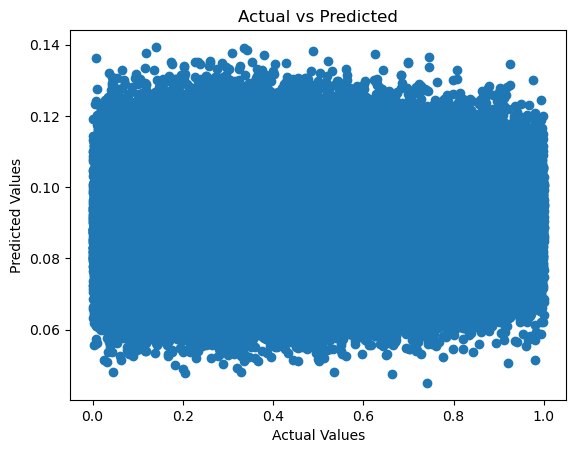

In [7]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

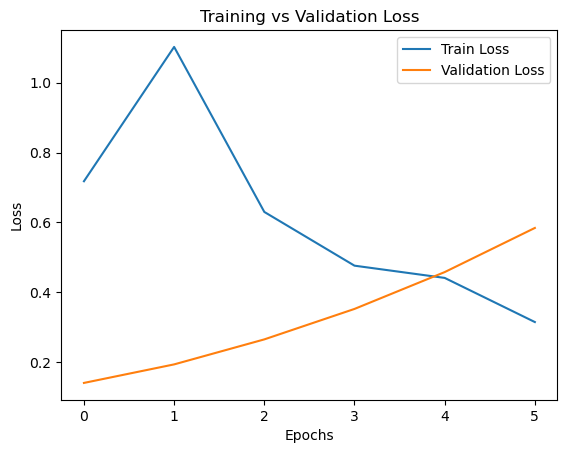

In [8]:
import matplotlib.pyplot as plt

# Assuming 'history' is the object returned by model.fit()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()